In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\ishan\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.stats import gaussian_kde


In [2]:
df = pd.read_csv('used_car_price_prediction.csv')

In [3]:
df.sample(10)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
487404,Ford,Figo,2012,10.271958,1815.911484,173.902437,Petrol,Manual,First,Grey,Hyderabad,281190,0,1,0,1,5,5,13,7.811591e+05
224050,Ford,Figo,2024,13.615984,854.031705,93.523702,Petrol,Manual,Third,Black,Hyderabad,7124,1,0,1,1,5,7,1,1.074036e+06
181633,Volkswagen,Polo,2012,14.742476,1499.064749,123.853423,diesel,Manual,Second,Blue,Bangalore,173264,1,0,0,1,5,7,13,7.030425e+05
400941,Mahindra,XUV700,2006,22.664329,1534.556535,103.424974,Diesel,Manual,First,Brown,Pune,455601,1,0,0,1,5,5,19,5.281386e+05
589980,BMW,X3,2014,8.514275,2551.725569,194.243101,Petrol,Manual,First,Brown,NaN,107778,1,0,1,1,4,5,11,1.453280e+06
459803,Hyundai,Verna,2016,20.311273,1765.266228,147.833208,CNG,Manual,First,Blue,Mumbai,175707,1,1,0,0,5,4,9,6.322871e+05
728573,Mahindra,Scorpio,2008,NaN,1513.932901,102.548603,Hybrid,Manual,First,Brown,Delhi,189414,1,0,0,1,5,7,17,5.000000e+04
869442,Ford,Figo,2023,19.811585,1227.280795,113.202349,Petrol,Manual,First,Silver,Kolkata,34676,1,1,0,1,4,5,2,5.024452e+05
74487,Honda,City,2024,14.069665,800.000000,NaN,Petrol,Manual,First,Blue,Mumbai,19236,1,1,2,1,4,5,1,6.796625e+05
259007,Toyota,Corolla,2023,20.523146,2217.976547,150.419313,Diesel,Automatic,First,Brown,Pune,48722,1,1,1,1,4,5,2,8.260293e+05


In [4]:
df['Mileage_kmpl'].isnull().sum()

np.int64(80390)

In [5]:
df=df[df["Mileage_kmpl"].isnull() == False]

In [6]:
df.shape

(924610, 20)

In [7]:
df=df[df["Engine_CC"].isnull()==False]
df

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
0,Toyota,Camry,2001,19.615852,1396.560379,NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,3.531896e+05
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05
6,Hyundai,i20,2014,16.328654,1398.722600,111.846497,Diesel,Manual,First,NaN,Chennai,200343,1,0,0,1,4,4,11,4.953191e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004993,Tata,Harrier,2017,23.199875,1563.247126,NaN,Petrol,Manual,First,White,Kolkata,162568,1,0,0,1,5,5,8,9.951965e+05
1004995,Nissan,Magnite,2022,12.256422,1773.657889,117.574596,Petrol,Manual,First,Black,Ahmedabad,68571,1,0,0,1,4,5,3,1.104233e+06
1004997,Skoda,Octavia,2018,21.665335,1447.159515,NaN,Petrol,NaN,First,Brown,Delhi,42140,0,1,0,1,4,4,7,1.304198e+06
1004998,BMW,X3,2010,17.852635,2179.906631,NaN,Petrol,Manual,First,Brown,Mumbai,211980,0,1,0,1,4,7,15,1.866610e+06


In [8]:
df=df[df["Horsepower"].isnull()==False]

In [9]:
df

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Price
1,Hyundai,i20,2012,19.478608,1130.771005,137.021719,Petrol,NaN,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,9.596943e+05
2,Mahindra,Bolero,2008,17.469920,1766.466250,142.902960,NaN,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,2.920229e+05
4,Honda,Civic,2022,18.326833,1239.334935,121.505993,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,6.365208e+05
6,Hyundai,i20,2014,16.328654,1398.722600,111.846497,Diesel,Manual,First,NaN,Chennai,200343,1,0,0,1,4,4,11,4.953191e+05
7,Hyundai,Creta,2001,21.895120,800.000000,0.709766,Petrol,Manual,Second,White,Kolkata,228720,1,0,0,1,5,5,24,5.000000e+04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004988,Honda,Amaze,2020,8.097582,1641.225144,118.952121,Electric,Manual,First,Brown,Pune,50155,1,0,1,1,4,5,5,8.224758e+05
1004990,Skoda,Slavia,2008,13.935683,1287.775569,114.498130,Petrol,Manual,First,Red,Hyderabad,269892,1,1,0,0,4,7,17,3.963039e+05
1004991,Skoda,Slavia,2003,19.946978,1252.293439,115.394192,CNG,Manual,First,Grey,Bangalore,533082,1,1,0,1,4,2,22,5.000000e+04
1004995,Nissan,Magnite,2022,12.256422,1773.657889,117.574596,Petrol,Manual,First,Black,Ahmedabad,68571,1,0,0,1,4,5,3,1.104233e+06


In [25]:
df["Transmission"].unique()

array([nan, 'Automatic', 'Manual'], dtype=object)

In [10]:
X=df.iloc[:,3:6]
y=df["Price"]

In [11]:
X

,Mileage_kmpl,Engine_CC,Horsepower
1,19.478608,1130.771005,137.021719
2,17.469920,1766.466250,142.902960
4,18.326833,1239.334935,121.505993
6,16.328654,1398.722600,111.846497
7,21.895120,800.000000,0.709766
...,...,...,...
1004988,8.097582,1641.225144,118.952121
1004990,13.935683,1287.775569,114.498130
1004991,19.946978,1252.293439,115.394192
1004995,12.256422,1773.657889,117.574596


<Axes: xlabel='Engine_CC', ylabel='Density'>

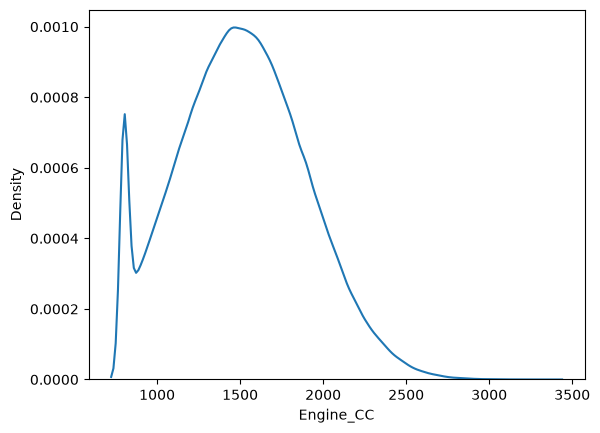

In [21]:
sns.kdeplot(df["Engine_CC"])

<Axes: xlabel='Engine_CC', ylabel='Mileage_kmpl'>

c:\Users\ishan\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\ishan\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


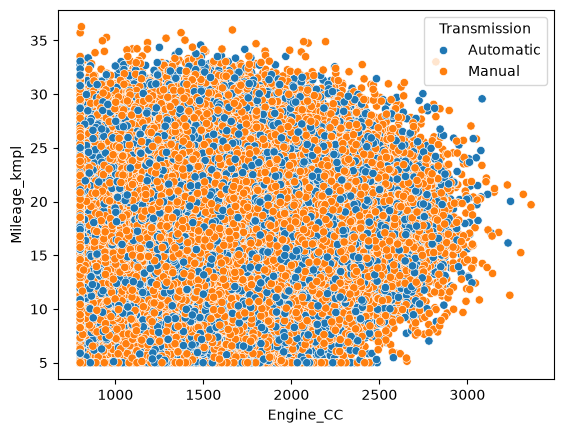

In [33]:
color_dict = {1: 'red', 2:'green', 3:'blue'}
sns.scatterplot(df, x=df['Engine_CC'], y=df['Mileage_kmpl'], hue=df['Transmission'], color=color_dict)

In [12]:
y

1          9.596943e+05
2          2.920229e+05
4          6.365208e+05
6          4.953191e+05
7          5.000000e+04
               ...     
1004988    8.224758e+05
1004990    3.963039e+05
1004991    5.000000e+04
1004995    1.104233e+06
1004999    5.000000e+04
Name: Price, Length: 782497, dtype: float64

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 0)

In [14]:
X_train.shape, X_test.shape

((625997, 3), (156500, 3))

In [15]:
X_train

,Mileage_kmpl,Engine_CC,Horsepower
611949,15.984391,1565.955529,129.098637
990444,6.538781,872.041413,91.605448
496817,16.907449,2373.772474,183.720259
183455,16.733879,1528.624776,100.788358
900155,17.179348,1687.256151,129.905033
...,...,...,...
462372,16.136638,1698.971565,127.341807
195810,24.023108,1307.012237,111.171985
151570,19.902769,938.612985,48.312149
560047,20.477718,1790.988013,162.435778


In [16]:
X_train.duplicated().sum()

np.int64(2504)

In [17]:
X_train.drop_duplicates()

,Mileage_kmpl,Engine_CC,Horsepower
611949,15.984391,1565.955529,129.098637
990444,6.538781,872.041413,91.605448
496817,16.907449,2373.772474,183.720259
183455,16.733879,1528.624776,100.788358
900155,17.179348,1687.256151,129.905033
...,...,...,...
462372,16.136638,1698.971565,127.341807
195810,24.023108,1307.012237,111.171985
151570,19.902769,938.612985,48.312149
560047,20.477718,1790.988013,162.435778


In [18]:
X_test.duplicated().sum()
X_test.drop_duplicates()

,Mileage_kmpl,Engine_CC,Horsepower
378809,12.805730,1200.257900,89.193046
146244,21.619452,1157.676926,78.908056
473828,16.366015,1882.133384,128.711177
640647,18.040246,1965.640768,169.408378
298285,24.979315,1900.372520,177.576621
...,...,...,...
147953,17.617018,1803.236879,139.697889
196281,27.425746,1147.598016,42.846338
889186,22.217374,1090.566947,92.922635
583066,16.699261,1194.839447,57.834351


In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [20]:
scaler.fit(X_train)

MinMaxScaler()

In [27]:
scaler.fit(X_train)


X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
X_train_scaled

array([[0.35114389, 0.29896507, 0.47806939],
       [0.04919102, 0.02811895, 0.35663782],
       [0.38065177, 0.61426934, 0.6549759 ],
       ...,
       [0.47640477, 0.05410293, 0.21642107],
       [0.49478446, 0.38679896, 0.5860405 ],
       [0.40872238, 0.3598967 , 0.41654137]], shape=(625997, 3))

In [30]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [31]:
np.round(X_train.describe(),1)

,Mileage_kmpl,Engine_CC,Horsepower
count,625997.0,625997.0,625997.0
mean,18.0,1506.6,120.6
std,4.0,385.7,36.8
min,5.0,800.0,-18.5
25%,15.3,1230.7,94.9
50%,18.0,1500.3,120.1
75%,20.7,1769.2,145.5
max,36.3,3362.0,290.2


In [32]:
np.round(X_train_scaled.describe(), 1)

,Mileage_kmpl,Engine_CC,Horsepower
count,625997.0,625997.0,625997.0
mean,0.4,0.3,0.5
std,0.1,0.2,0.1
min,0.0,0.0,0.0
25%,0.3,0.2,0.4
50%,0.4,0.3,0.4
75%,0.5,0.4,0.5
max,1.0,1.0,1.0
